---
# 1. **Exploratory Data Analysis** <a class="anchor" id="1"></a>
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,mean_squared_error
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor




In [2]:
data = pd.read_csv('heart.csv')
print('Shape of the data is ', data.shape)

Shape of the data is  (303, 14)


In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:

# 🔠 ترميز الأعمدة التصنيفية
encoders = {}
def encode(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].nunique() <= 10:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
    return df
# البيانات بعد الترميز
data_encoded = encode(data)

#  نسخة احتياطية
original_data = data_encoded.copy()

#  تطبيع البيانات
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_encoded), columns=data_encoded.columns)

#  حذف عشوائي لبعض القيم من الأعمدة (بدون المساس بـ target)
missing_ratio = 0.1
data_with_missing = data_scaled.copy()
missing_info = {}

for col in data_scaled.columns:
    if col == 'target':
        continue
    #  عدد القيم التي سيتم حذفها في العمود
    n_missing = int(missing_ratio * len(data_scaled))
    indices = random.sample(range(len(data_scaled)), n_missing)
    # نحتفظ بالقيم الأصلية للمقارنة لاحقًا (للتحقق من دقة التنبؤ).
    missing_info[col] = {
        'indices': indices,
        'true_values': original_data[col].iloc[indices].values
    }
    # نحذف هذه القيم فعليًا من البيانات
    data_with_missing.loc[indices, col] = np.nan
    
#  تدريب نموذج لكل عمود مفقود باستخدام target فقط
accuracies = []
regression_errors = []


for col in missing_info:    
    #  والمفقودةالقيم غير المفقودة
    available_rows = data_with_missing[col].notnull()
    missing_rows = data_with_missing[col].isnull()
    # فقط عمود target
    X_train = data_with_missing.loc[available_rows, ['target']]  # فقط target
    # القيم غير المفقودة لهذا العمود
    y_train = original_data.loc[available_rows, col]
    
    #القيم التي نريد التنبؤ بها (نعتمد على target)
    X_pred = data_with_missing.loc[missing_rows, ['target']]
    #القيم الأصلية (للمقارنة لاحقًا)

    y_true = missing_info[col]["true_values"]
    
    if len(X_pred) == 0:
        continue

    is_class = y_train.nunique() <= 10
    
    model = XGBClassifier(eval_metric='logloss') if is_class else XGBRegressor()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_pred)

    # ملء القيم المتنبأ بها
    data_with_missing.loc[missing_rows, col] = y_pred

    
'''
# فصل البيانات
X = data_with_missing.drop(columns=['target'])
y = original_data['target']  # الأصلية لأننا لا نحذف منها

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_target = RandomForestClassifier(n_estimators=200, random_state=42)
model_target.fit(X_train, y_train)
y_pred = model_target.predict(X_test)

acc_target = (accuracy_score(y_test, y_pred))*100
print("\n📊 : التنبؤ بـ target")
print(f"✅ دقة النموذج: {acc_target:.4f}")'''

'\n# فصل البيانات\nX = data_with_missing.drop(columns=[\'target\'])\ny = original_data[\'target\']  # الأصلية لأننا لا نحذف منها\n\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\nmodel_target = RandomForestClassifier(n_estimators=200, random_state=42)\nmodel_target.fit(X_train, y_train)\ny_pred = model_target.predict(X_test)\n\nacc_target = (accuracy_score(y_test, y_pred))*100\nprint("\n📊 : التنبؤ بـ target")\nprint(f"✅ دقة النموذج: {acc_target:.4f}")'

## 1.2 **Data pre-processing** <a class="anchor" id="1.2"></a>
### 1.2.1 Drop faulty data
Based on our investigation we did above, we will drop 7 rows.

In [8]:
data = data[data['ca'] < 4] #drop the wrong ca values
data = data[data['thal'] > 0] # drop the wong thal value
print(f'The length of the data now is {len(data)} instead of 303!')

The length of the data now is 296 instead of 303!


### إعادة تسمية الأعمدة

In [9]:
data = data.rename(
    columns = {'cp':'chest_pain_type',# نوع ألم الصدر الذي يعاني منه المريض
               'trestbps':'resting_blood_pressure', # 	ضغط الدم أثناء الراحة 
               'chol': 'cholesterol',#مستوى الكولسترول في الدم
               'fbs': 'fasting_blood_sugar',# نسبة السكر في الدم بعد صيام
               'restecg' : 'resting_electrocardiogram',# نتائج تخطيط القلب أثناء الراحة
               'thalach': 'max_heart_rate_achieved', #أعلى معدل نبضات قلب تم الوصول إليه أثناء الفحص
               'exang': 'exercise_induced_angina',# هل هناك ألم صدر ناجم عن التمارين؟
               'oldpeak': 'st_depression', # مقياس يشير إلى وجود مشاكل في القلب
               'slope': 'st_slope', # ميل موجة ST في تخطيط القلب
               'ca':'num_major_vessels', #عدد الأوعية الدموية الرئيسية الملونة بالأشعة (من 0 إلى 3) 
               'thal': 'thalassemia'}, # حالة الثلاسيميا
    errors="raise")             

### تحويل القيم الرقمية إلى وصفية

In [10]:
data['sex'][data['sex'] == 0] = 'female'
data['sex'][data['sex'] == 1] = 'male'
# نوع ألم الصدر الذي يعاني منه المريض
data['chest_pain_type'][data['chest_pain_type'] == 0] = 'typical angina'#  ألم صدري تقليدي
data['chest_pain_type'][data['chest_pain_type'] == 1] = 'atypical angina' # ألم غير تقليدي
data['chest_pain_type'][data['chest_pain_type'] == 2] = 'non-anginal pain' # الم غير ذبحي
data['chest_pain_type'][data['chest_pain_type'] == 3] = 'asymptomatic' # بدون أعراض
# نسبة السكر في الدم بعد صيام
data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 0] = 'lower than 120mg/ml'
data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 1] = 'greater than 120mg/ml'
# نتائج تخطيط القلب أثناء الراحة
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 0] = 'normal'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 1] = 'ST-T wave abnormality'# اضطراب موجة ST-T
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 2] = 'left ventricular hypertrophy' # تضخم البطين الايسر
# هل هناك ألم صدر ناجم عن التمارين
data['exercise_induced_angina'][data['exercise_induced_angina'] == 0] = 'no'
data['exercise_induced_angina'][data['exercise_induced_angina'] == 1] = 'yes'
# ميل موجة ST في تخطيط القلب
data['st_slope'][data['st_slope'] == 0] = 'upsloping' # منحدر للاعلى
data['st_slope'][data['st_slope'] == 1] = 'flat' # مسطح
data['st_slope'][data['st_slope'] == 2] = 'downsloping' # منحدر للاسفل
# حالة الثلاسيميا
data['thalassemia'][data['thalassemia'] == 1] = 'fixed defect' #خلل دائم
data['thalassemia'][data['thalassemia'] == 2] = 'normal' 
data['thalassemia'][data['thalassemia'] == 3] = 'reversable defect' #خلل يمكن عكسه

C:\Users\PYTHONIST\AppData\Local\Temp\ipykernel_6216\2935908424.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['sex'][data['sex'] == 0] = 'female'
C:\Users\PYTHONIST\AppData\Local\Temp\ipykernel_6216\2935908424.py:1: SettingWithCop

In [11]:
data.dtypes

age                            int64
sex                           object
chest_pain_type               object
resting_blood_pressure         int64
cholesterol                    int64
fasting_blood_sugar           object
resting_electrocardiogram     object
max_heart_rate_achieved        int64
exercise_induced_angina       object
st_depression                float64
st_slope                      object
num_major_vessels              int64
thalassemia                   object
target                         int64
dtype: object

In [12]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,greater than 120mg/ml,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,lower than 120mg/ml,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,lower than 120mg/ml,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,lower than 120mg/ml,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,lower than 120mg/ml,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


### 1.2.3 Grouping Features (by data type) تصنيف المتغيرات



In [13]:
# numerical fearures 6
num_feats = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels']
cat_feats = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiogram',
            'exercise_induced_angina', 'st_slope', 'thalassemia']

## وصفي

###   ?  توزيع الجنس
 الرجال أكثر بكثير من النساء


Text(0.5, 1.0, 'Distribution of target variable')

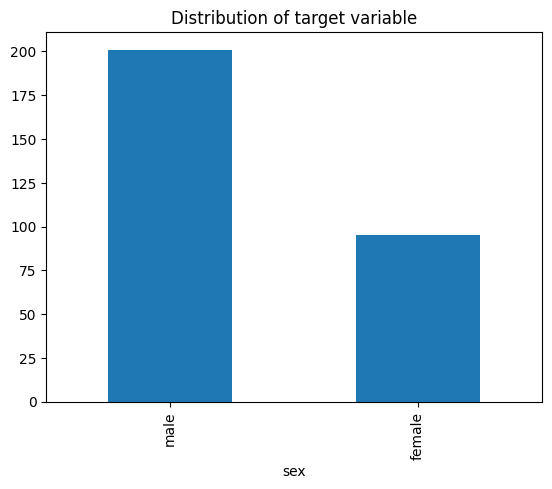

In [14]:
plt.figure()
data['sex'].value_counts().plot(kind='bar')
plt.title('Distribution of target variable')


###  توزيع الأعمار ?
 أغلب المرضى بين 50–60 سنة


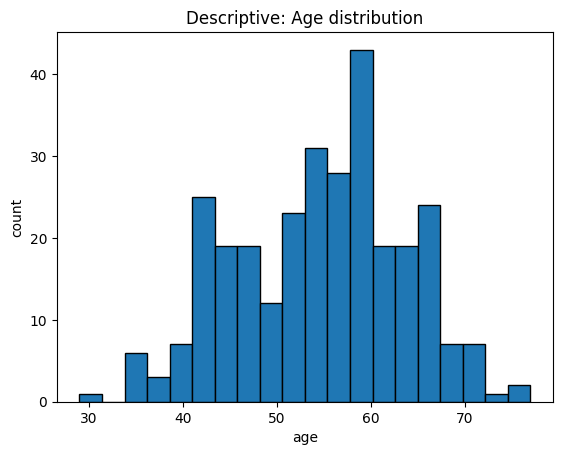

In [15]:
x = data["age"].dropna()
plt.figure()
plt.hist(x, bins=20, edgecolor="black")
plt.title("Descriptive: Age distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.show()


####  من  اكثر اصابة بمرض القلب الاناث ام الذكور؟   

نسبة الإصابة بمرض القلب لدى female: 74.74%
نسبة الإصابة بمرض القلب لدى male: 44.28%


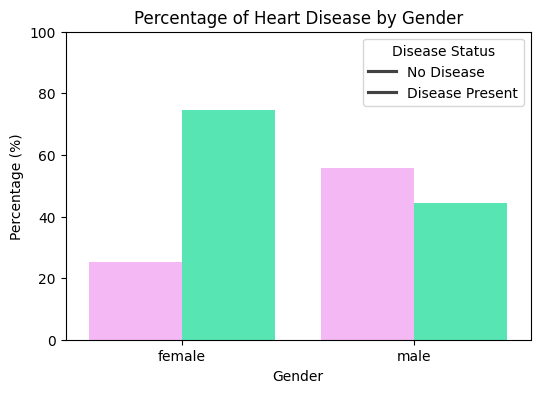

In [16]:
mypal= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA']
# عدد المرضى حسب الجنس والإصابة
gender_target_counts = data.groupby(['sex', 'target']).size().unstack(fill_value=0)

# حساب العدد الكلي لكل جنس
gender_total = gender_target_counts.sum(axis=1)

# حساب نسبة الإصابة (target = 1)
gender_target_percent = (gender_target_counts[1] / gender_total) * 100

# طباعة النتائج
for gender in gender_target_percent.index:
    percent = gender_target_percent[gender]
    print(f"نسبة الإصابة بمرض القلب لدى {gender}: {percent:.2f}%")

# حساب التوزيع النسبي لكل جنس بحسب الإصابة
gender_dist = data.groupby(['sex', 'target']).size().reset_index(name='count')

# حساب النسبة المئوية داخل كل جنس
gender_total = gender_dist.groupby('sex')['count'].transform('sum')
gender_dist['percentage'] = (gender_dist['count'] / gender_total) * 100

# رسم النسبة المئوية
plt.figure(figsize=(6, 4))
sns.barplot(data=gender_dist, x='sex', y='percentage', hue='target', palette=mypal[1::4])
plt.title("Percentage of Heart Disease by Gender")
plt.ylabel('Percentage (%)')
plt.xlabel('Gender')
plt.legend(title='Disease Status', labels=['No Disease', 'Disease Present'])
plt.ylim(0, 100)
plt.show()

C:\Users\PYTHONIST\AppData\Local\Temp\ipykernel_6216\749100919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data['target'], palette=mypal[1::4])


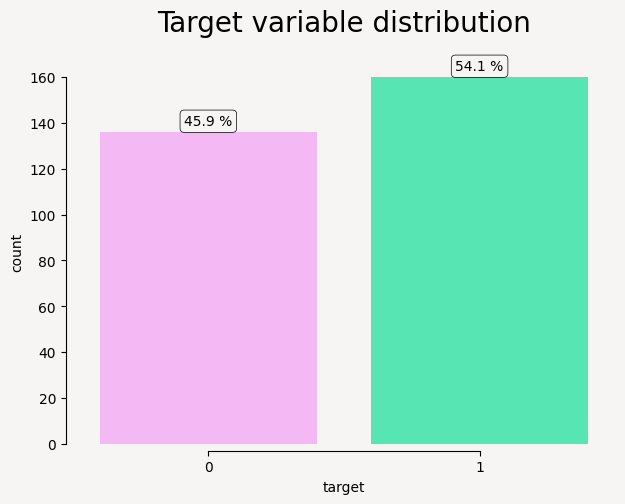

In [17]:
mypal= ['#FC05FB', '#FEAEFE', '#FCD2FC','#F3FEFA', '#B4FFE4','#3FFEBA']

plt.figure(figsize=(7, 5),facecolor='#F6F5F4')
total = float(len(data))
ax = sns.countplot(x=data['target'], palette=mypal[1::4])
ax.set_facecolor('#F6F5F4')

for p in ax.patches:
    
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,height + 3,'{:1.1f} %'.format((height/total)*100), ha="center",
           bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', linewidth=0.5))

ax.set_title('Target variable distribution', fontsize=20, y=1.05)
sns.despine(right=True)
sns.despine(offset=5, trim=True)

## تشخيصي

###  الكولسترول مقابل الإصابة ? 


C:\Users\PYTHONIST\AppData\Local\Temp\ipykernel_6216\1572966288.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y0, y1], labels=["target=0","target=1"])


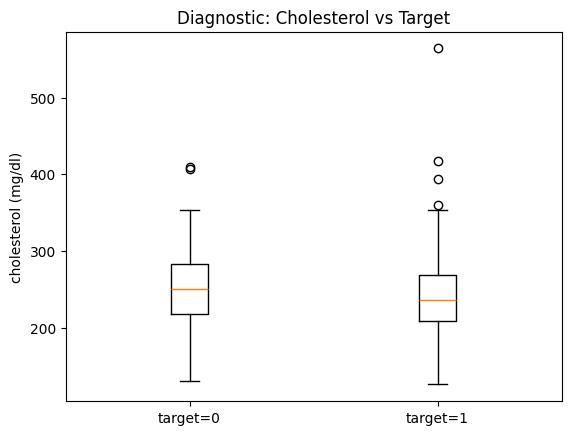

In [18]:
y0 = data.loc[data["target"]==0, "cholesterol"].dropna()
y1 = data.loc[data["target"]==1, "cholesterol"].dropna()
plt.figure()
plt.boxplot([y0, y1], labels=["target=0","target=1"])
plt.title("Diagnostic: Cholesterol vs Target")
plt.ylabel("cholesterol (mg/dl)")
plt.show()


###  العمر مقابل الإصابة  ؟ 
مرضى القلب (target=1) غالبًا أكبر سنًا من غير المصابين.

C:\Users\PYTHONIST\AppData\Local\Temp\ipykernel_6216\4022483073.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y0, y1], labels=["target=0","target=1"])


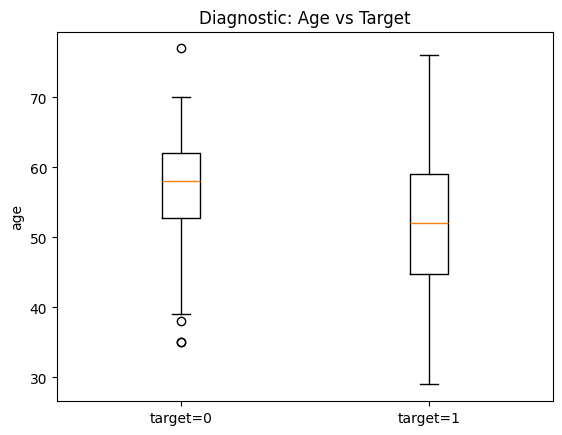

In [19]:
y0 = data.loc[data["target"]==0, "age"].dropna()
y1 = data.loc[data["target"]==1, "age"].dropna()
plt.figure()
plt.boxplot([y0, y1], labels=["target=0","target=1"])
plt.title("Diagnostic: Age vs Target")
plt.ylabel("age")
plt.show()


## الكولسترول والعمر يرتبطان بقوة بوجود المرض.

## تنبؤي

###  الصدر (cp) مقابل الحالة؟
مرضى القلب يتركزون في فئة asymptomatic (cp=0) → أي غياب الألم لا ينفي المرض.   

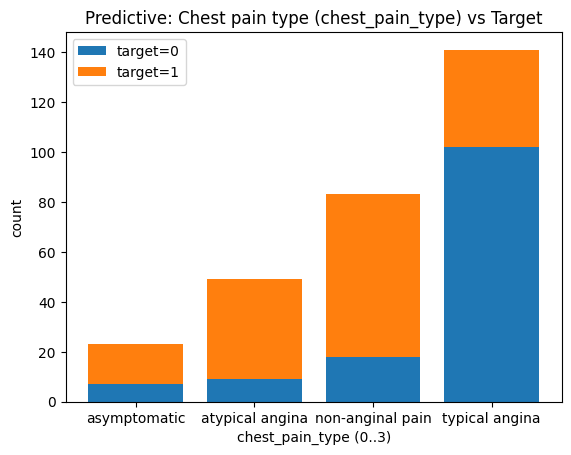

In [20]:
tmp = data[["chest_pain_type","target"]].dropna()
tab = pd.crosstab(tmp["chest_pain_type"], tmp["target"]).sort_index()
if 0 not in tab.columns: tab[0]=0
if 1 not in tab.columns: tab[1]=0
idx = tab.index.astype(str)
plt.figure()
plt.bar(idx, tab[0].values, label="target=0")
plt.bar(idx, tab[1].values, bottom=tab[0].values, label="target=1")
plt.title("Predictive: Chest pain type (chest_pain_type) vs Target")
plt.xlabel("chest_pain_type (0..3)")
plt.ylabel("count")
plt.legend()
plt.show()


### العمر × أقصى نبض (max_heart_rate_achieved)؟
النقاط الملونة تُظهر أن كبار السن عادة لديهم معدل نبض أقصى أقل، ومعهم احتمال إصابة أعلى.

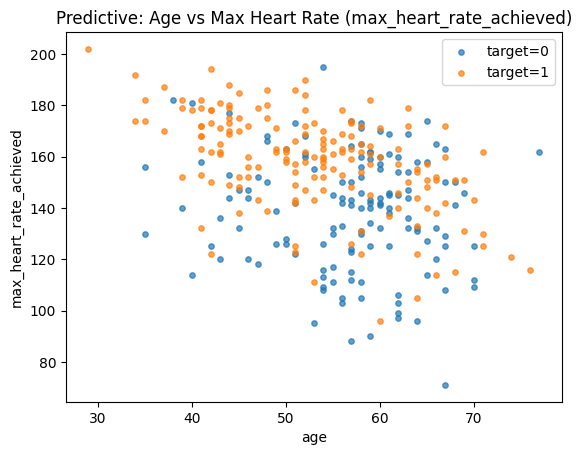

In [21]:
# خلية 6: age vs thalach
m1 = data["target"]==1
m0 = data["target"]==0
plt.figure()
plt.scatter(data.loc[m0,"age"], data.loc[m0,"max_heart_rate_achieved"], s=15, alpha=0.7, label="target=0")
plt.scatter(data.loc[m1,"age"], data.loc[m1,"max_heart_rate_achieved"], s=15, alpha=0.7, label="target=1")
plt.title("Predictive: Age vs Max Heart Rate (max_heart_rate_achieved)")
plt.xlabel("age")
plt.ylabel("max_heart_rate_achieved")
plt.legend()
plt.show()


## أنواع ألم الصدر والنبض الأقصى مع العمر تصلح كمؤشرات تنبؤية قوية.

## توجيهي

### عدد الأوعية (num_major_vessels) مقابل الحالة

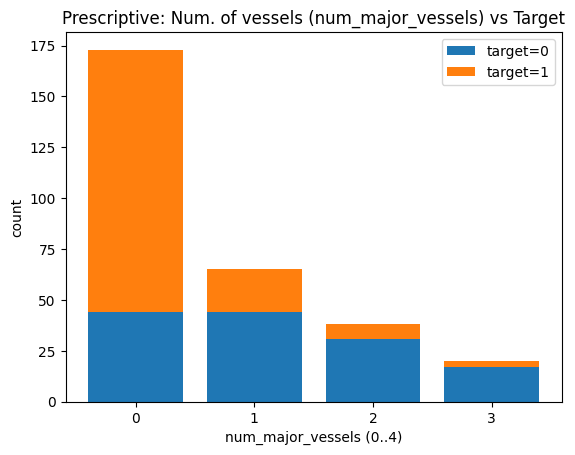

In [22]:
# خلية 7: ca مكدّس حسب الحالة
tmp = data[["num_major_vessels","target"]].dropna()
tab = pd.crosstab(tmp["num_major_vessels"], tmp["target"]).sort_index()
if 0 not in tab.columns: tab[0]=0
if 1 not in tab.columns: tab[1]=0
idx = tab.index.astype(str)
plt.figure()
plt.bar(idx, tab[0].values, label="target=0")
plt.bar(idx, tab[1].values, bottom=tab[0].values, label="target=1")
plt.title("Prescriptive: Num. of vessels (num_major_vessels) vs Target")
plt.xlabel("num_major_vessels (0..4)")
plt.ylabel("count")
plt.legend()
plt.show()


## مقارن

###   معدل الإصابة حسب الجنس
النساء أقل عددًا لكن عند وجود عوامل الخطر فهن أكثر عرضة نسبيًا.

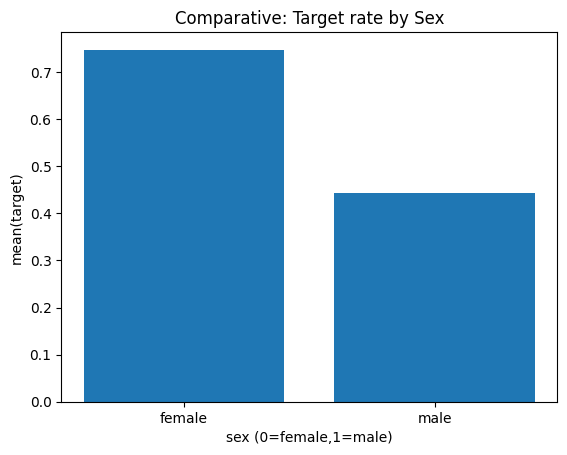

In [23]:
tmp = data[["sex","target"]].dropna()
rate = tmp.groupby("sex")["target"].mean().sort_index()
plt.figure()
plt.bar(rate.index.astype(str), rate.values)
plt.title("Comparative: Target rate by Sex")
plt.xlabel("sex (0=female,1=male)")
plt.ylabel("mean(target)")
plt.show()


## استكشافي (للبحث عن أنماط/كتل/علاقات خفية بين متغيرين مهمّين)

###  age vs cholesterol
البيانات تُظهر أنماطًا مخفية يمكن استكشافها أكثر بالـ Clustering.

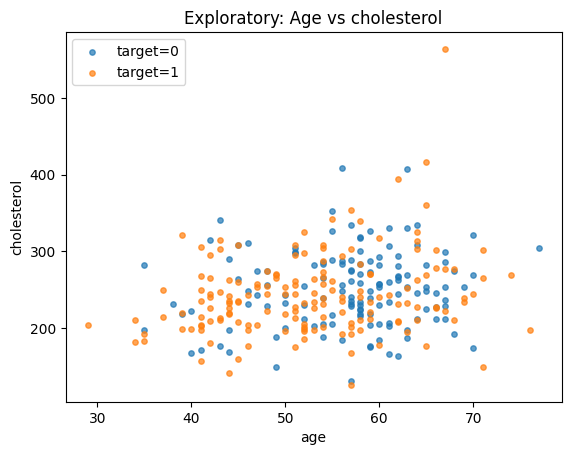

In [24]:
# خلية 10: age vs cholesterol
m1 = data["target"]==1
m0 = data["target"]==0
plt.figure()
plt.scatter(data.loc[m0,"age"], data.loc[m0,"cholesterol"], s=15, alpha=0.7, label="target=0")
plt.scatter(data.loc[m1,"age"], data.loc[m1,"cholesterol"], s=15, alpha=0.7, label="target=1")
plt.title("Exploratory: Age vs cholesterol")
plt.xlabel("age")
plt.ylabel("cholesterol")
plt.legend()
plt.show()


## سببي (استدلال بصري) 
## لاستكشاف تآثر محتمل بين العمر والضغط على الحالة

### ضغط الدم × العمر
الرسم يظهر أن ارتفاع الضغط مع التقدم في العمر يرتبط بزيادة الإصابات.

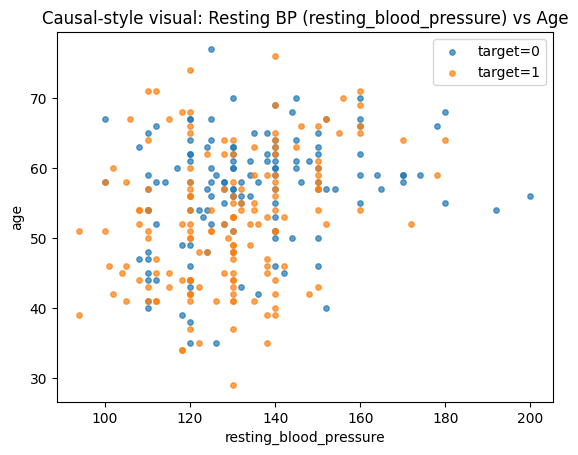

In [25]:
m1 = data["target"]==1
m0 = data["target"]==0
plt.figure()
plt.scatter(data.loc[m0,"resting_blood_pressure"], data.loc[m0,"age"], s=15, alpha=0.7, label="target=0")
plt.scatter(data.loc[m1,"resting_blood_pressure"], data.loc[m1,"age"], s=15, alpha=0.7, label="target=1")
plt.title("Causal-style visual: Resting BP (resting_blood_pressure) vs Age")
plt.xlabel("resting_blood_pressure")
plt.ylabel("age")
plt.legend()
plt.show()


## ضغط الدم مع العمر معًا يلعبان دورًا سببيًا محتملًا

## ماذا لو
### كيف تتغير الخطورة لو تغيّر العمر (احتمال المرض عبر العمر)
الخط يوضح أن احتمال الإصابة يرتفع تدريجيًا بعد سن 50 ويظل عاليًا حتى 70

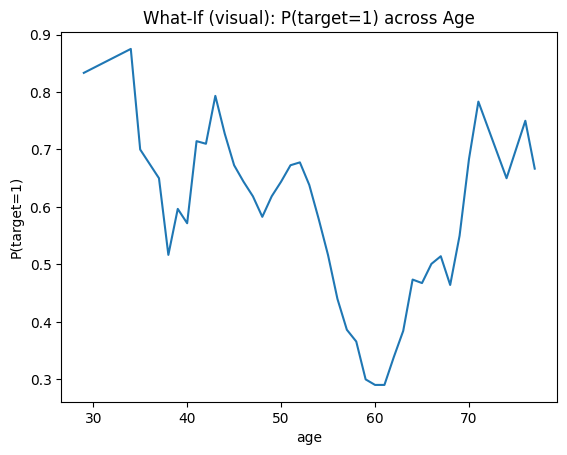

In [26]:
# خلية 11: P(target=1) عبر العمر
tmp = data[["age","target"]].dropna()
p = tmp.groupby("age")["target"].mean().sort_index()
# تنعيم بسيط
if len(p) >= 5:
    p = p.rolling(5, center=True, min_periods=1).mean()
plt.figure()
plt.plot(p.index.values, p.values)
plt.title("What-If (visual): P(target=1) across Age")
plt.xlabel("age")
plt.ylabel("P(target=1)")
plt.show()


## العمر وحده متغير مهم جدًا

## تجزئة
### محوران سريريان مهمّان قد يظهران شرائح مرضى مختلفة 
النقاط تظهر مجموعتين رئيسيتين: مرضى مع st_depression منخفض + max_heart_rate_achieved عالي (أصحاء غالبًا) مقابل مرضى مع oldpeak مرتفع + thalach منخفض.

🔑  يمكن تقسيم المرضى إلى شرائح مميزة حسب هذه المؤشرات.

### st_depression vs max_heart_rate_achieved

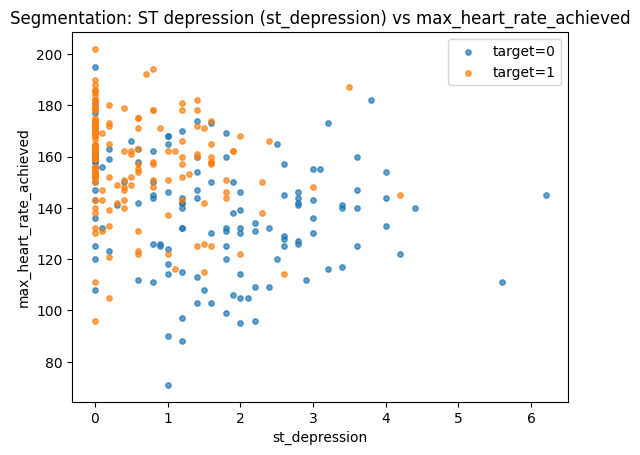

In [27]:
m1 = data["target"]==1
m0 = data["target"]==0
plt.figure()
plt.scatter(data.loc[m0,"st_depression"], data.loc[m0,"max_heart_rate_achieved"], s=15, alpha=0.7, label="target=0")
plt.scatter(data.loc[m1,"st_depression"], data.loc[m1,"max_heart_rate_achieved"], s=15, alpha=0.7, label="target=1")
plt.title("Segmentation: ST depression (st_depression) vs max_heart_rate_achieved")
plt.xlabel("st_depression")
plt.ylabel("max_heart_rate_achieved")
plt.legend()
plt.show()


<!-- def cat_freq_counter(df, columns):
    dataFrames_ = []
    for col in columns:
        dataFrames_.append(pd.DataFrame(df[col].value_counts()).style.background_gradient(cmap='cool'))
    return HTML(f"<table><tr> {''.join(['<td>' + dfs._repr_html_() + '</td>' for dfs in dataFrames_])} </tr></table>")

# split the width of the output 
display(cat_freq_counter(data, cat_feats[0:4]))
display(cat_freq_counter(data, cat_feats[4:])) -->

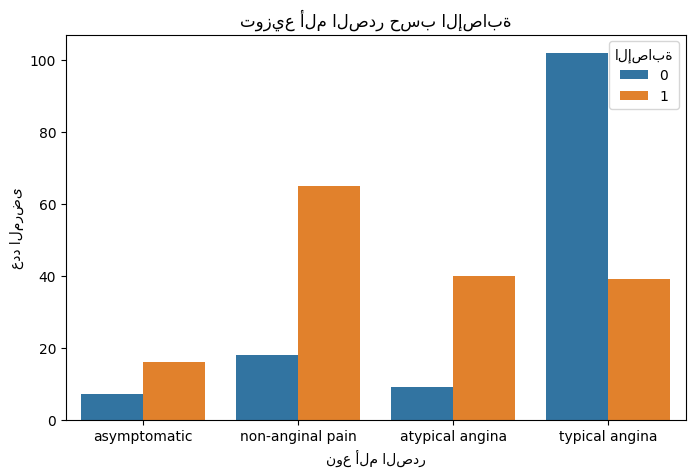

In [28]:
# هل نوع ألم الصدر `chest_pain_type` يزيد احتمالية الإصابة؟
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='chest_pain_type', hue='target')
plt.title("توزيع ألم الصدر حسب الإصابة")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد المرضى")
plt.legend(title='الإصابة')
plt.show()

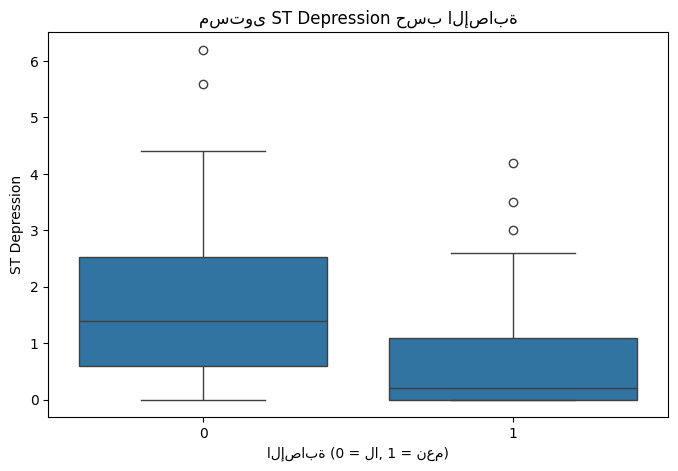

In [29]:
# إذا كان هناك مشكلة في موجة ST (`st_depression`)، هل يقلل ذلك من فرص النجاة؟
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='target', y='st_depression')
plt.title("مستوى ST Depression حسب الإصابة")
plt.xlabel("الإصابة (0 = لا, 1 = نعم)")
plt.ylabel("ST Depression")
plt.show()

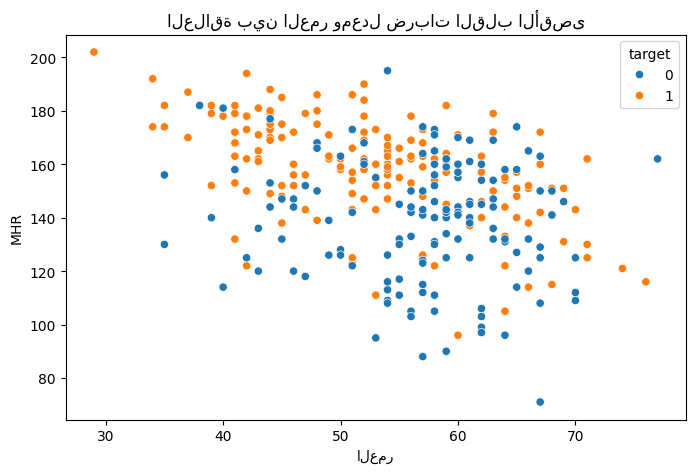

In [30]:
# هل معدل ضربات القلب max_heart_rate_achieved ينخفض كلما تقدم المرضى في العمر؟

plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='max_heart_rate_achieved', hue='target')
plt.title("العلاقة بين العمر ومعدل ضربات القلب الأقصى")
plt.xlabel("العمر")
plt.ylabel("MHR")
plt.show()

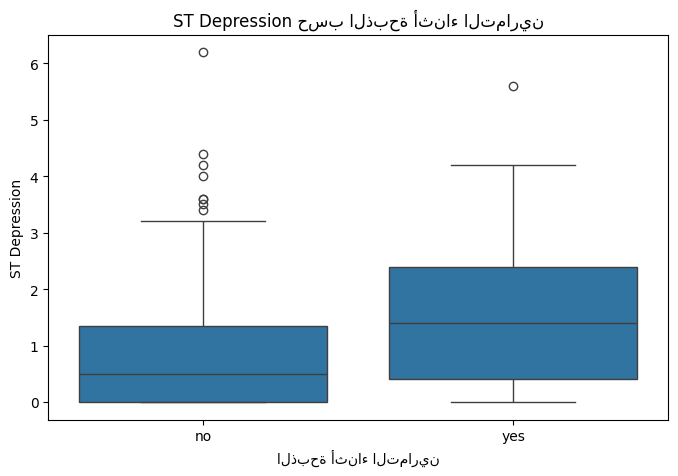

In [31]:
# هل وجود ألم في التمارين مرتبط بـ st_depression؟

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='exercise_induced_angina', y='st_depression')
plt.title("ST Depression حسب الذبحة أثناء التمارين")
plt.xlabel("الذبحة أثناء التمارين")
plt.ylabel("ST Depression")
plt.show()

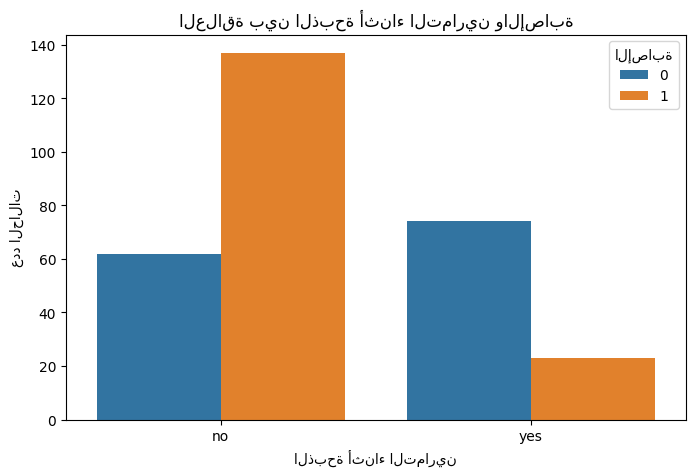

In [32]:
# هل إذا كان ألم الصدر ناجم عن التمارين يزيد الإصابة؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='exercise_induced_angina', hue='target')
plt.title("العلاقة بين الذبحة أثناء التمارين والإصابة")
plt.xlabel("الذبحة أثناء التمارين")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

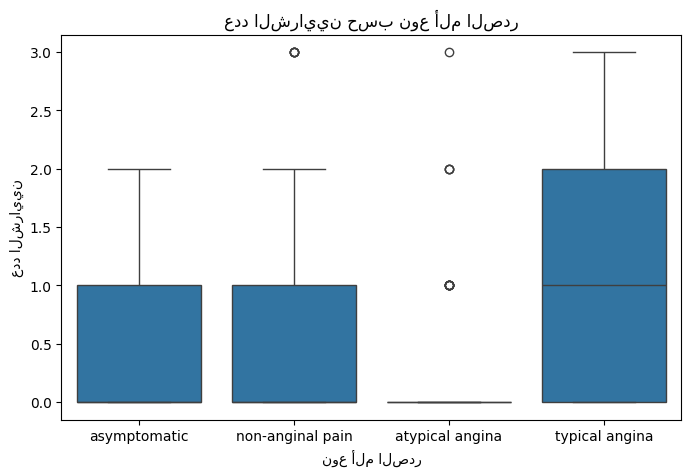

In [33]:
# هل نوع ألم الصدر يختلف مع عدد الشرايين؟

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='chest_pain_type', y='num_major_vessels')
plt.title("عدد الشرايين حسب نوع ألم الصدر")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الشرايين")
plt.show()

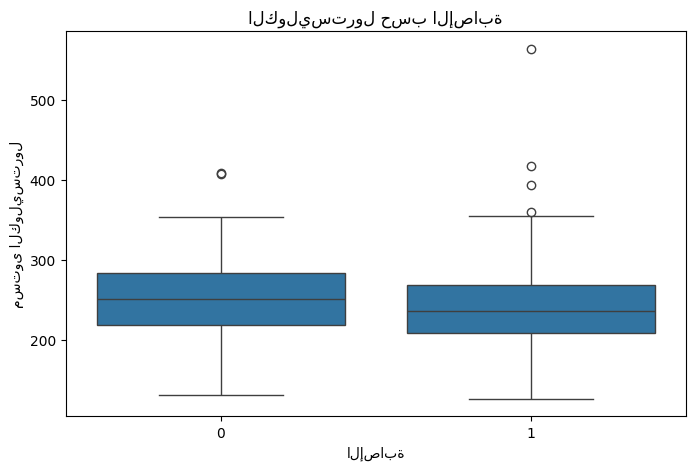

In [34]:
# هل الأشخاص الذين لديهم كوليسترول مرتفع أكثر عرضة؟

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='target', y='cholesterol')
plt.title("الكوليسترول حسب الإصابة")
plt.xlabel("الإصابة")
plt.ylabel("مستوى الكوليسترول")
plt.show()

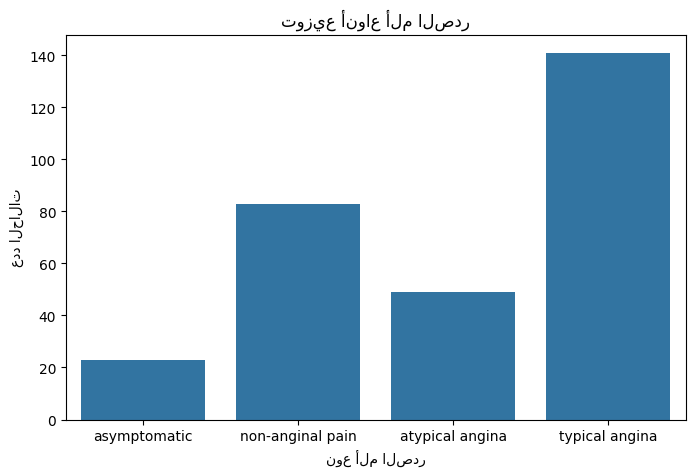

In [35]:
# ما أنواع ألم الصدر الأكثر شيوعًا؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='chest_pain_type')
plt.title("توزيع أنواع ألم الصدر")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الحالات")
plt.show()

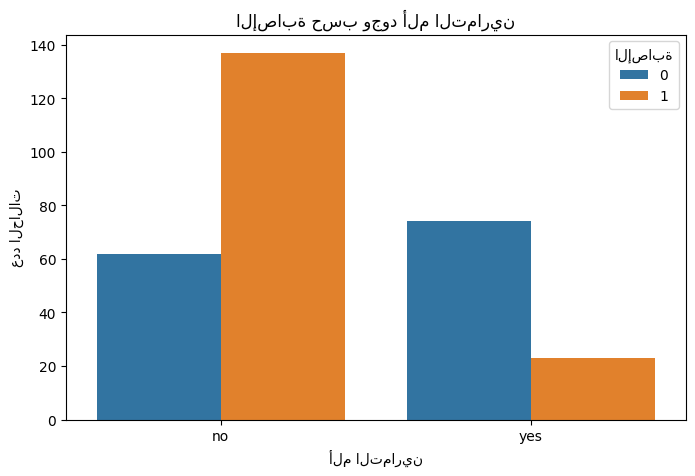

In [36]:
# ما نسبة الإصابة بين من لديهم ألم صدر ناتج عن التمارين؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='exercise_induced_angina', hue='target')
plt.title("الإصابة حسب وجود ألم التمارين")
plt.xlabel("ألم التمارين")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

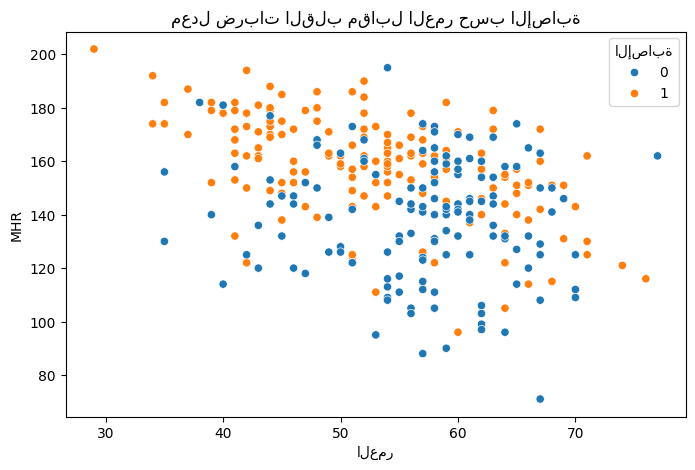

In [37]:
# معدل ضربات القلب مع العمر للمصابين وغير المصابين

plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='max_heart_rate_achieved', hue='target')
plt.title("معدل ضربات القلب مقابل العمر حسب الإصابة")
plt.xlabel("العمر")
plt.ylabel("MHR")
plt.legend(title='الإصابة')
plt.show()

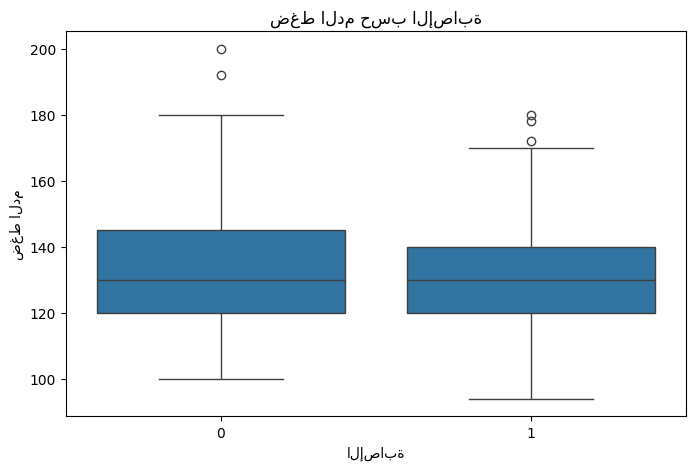

In [38]:
# نسبة ارتفاع ضغط الدم للمصابين

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='target', y='resting_blood_pressure')
plt.title("ضغط الدم حسب الإصابة")
plt.xlabel("الإصابة")
plt.ylabel("ضغط الدم")
plt.show()

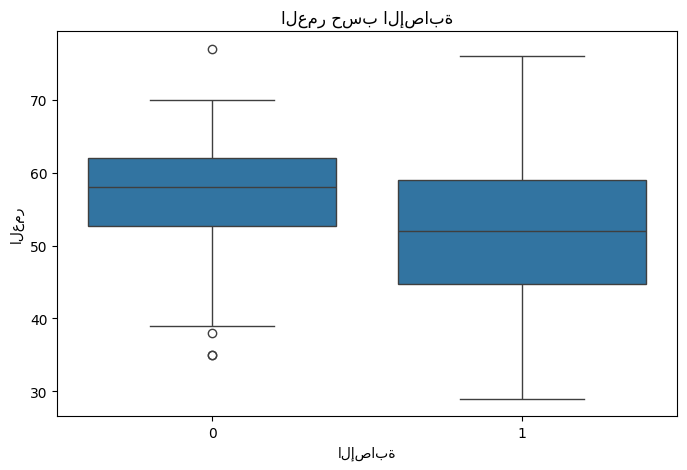

In [39]:
# ما العمر سبب الإصابة؟

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='target', y='age')
plt.title("العمر حسب الإصابة")
plt.xlabel("الإصابة")
plt.ylabel("العمر")
plt.show()

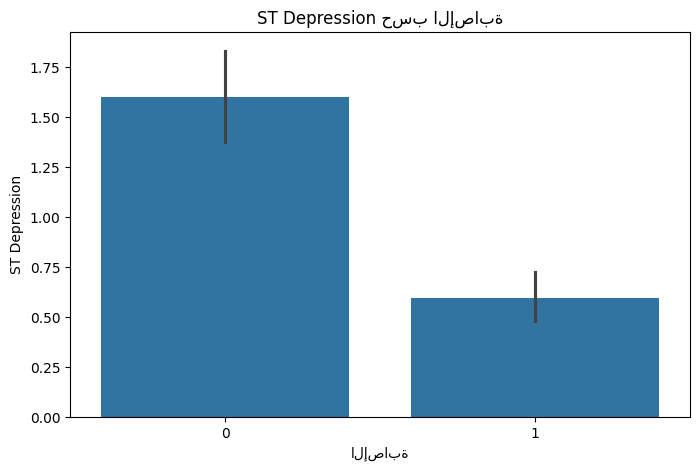

In [40]:
# إذا كان يوجد مشكلة في القلب، هل يعني ذلك ارتفاع st_depression؟

plt.figure(figsize=(8,5))
sns.barplot(data=data, x='target', y='st_depression')
plt.title("ST Depression حسب الإصابة")
plt.xlabel("الإصابة")
plt.ylabel("ST Depression")
plt.show()

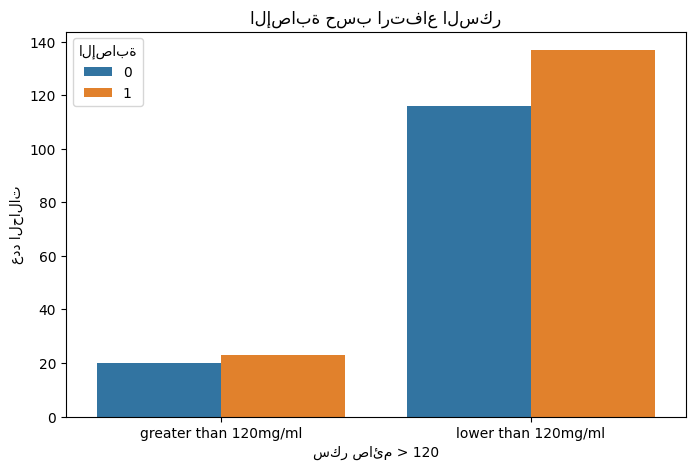

In [41]:
# هل نسبة السكر العالية مرتبطة بالإصابة؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='fasting_blood_sugar', hue='target')
plt.title("الإصابة حسب ارتفاع السكر")
plt.xlabel("سكر صائم > 120")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

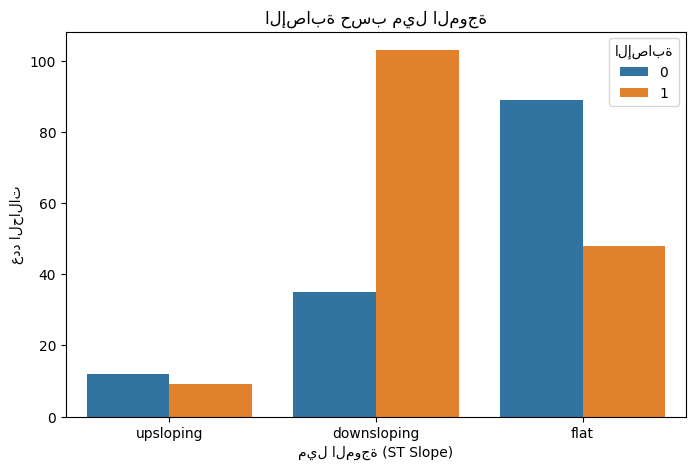

In [42]:
# هل إذا كان ميل الموجة منخفض في التخطيط القلبي يدل على وجود مرض؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='st_slope', hue='target')
plt.title("الإصابة حسب ميل الموجة")
plt.xlabel("ميل الموجة (ST Slope)")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

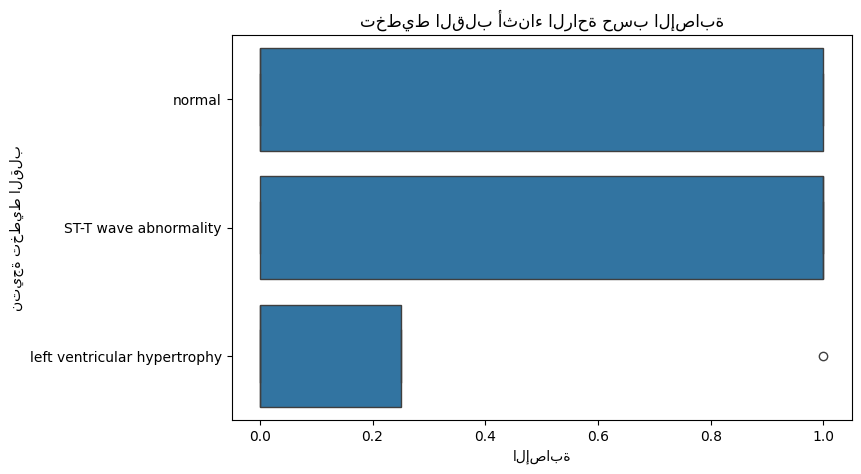

In [43]:
# هل الأشخاص الذين لديهم تخطيط قلب عالي لديهم خطر أكبر؟

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='target', y='resting_electrocardiogram')
plt.title("تخطيط القلب أثناء الراحة حسب الإصابة")
plt.xlabel("الإصابة")
plt.ylabel("نتيجة تخطيط القلب")
plt.show()

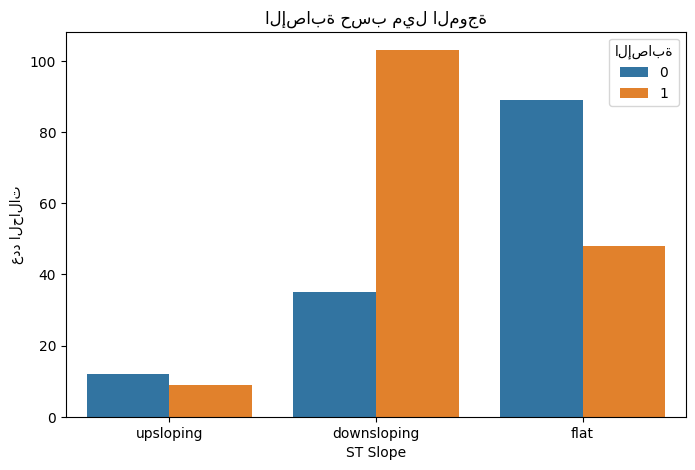

In [44]:
# إذا كان ميل الموجة في التخطيط مرتفع، هل يقلل من خطر الإصابة؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='st_slope', hue='target')
plt.title("الإصابة حسب ميل الموجة")
plt.xlabel("ST Slope")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

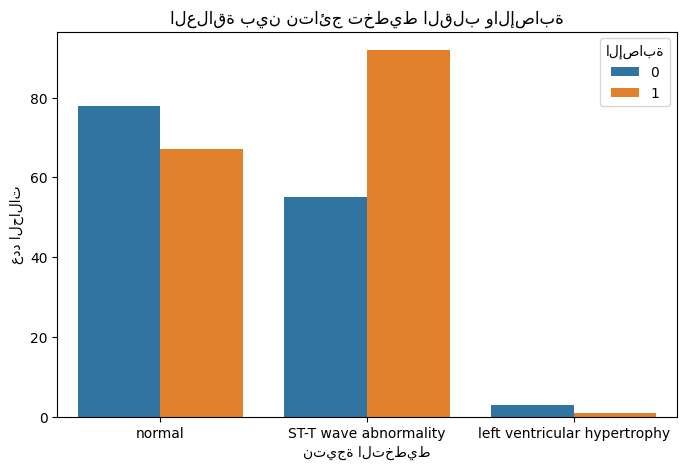

In [45]:
# هل نتائج تخطيط القلب ترتبط بوجود مرض؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='resting_electrocardiogram', hue='target')
plt.title("العلاقة بين نتائج تخطيط القلب والإصابة")
plt.xlabel("نتيجة التخطيط")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

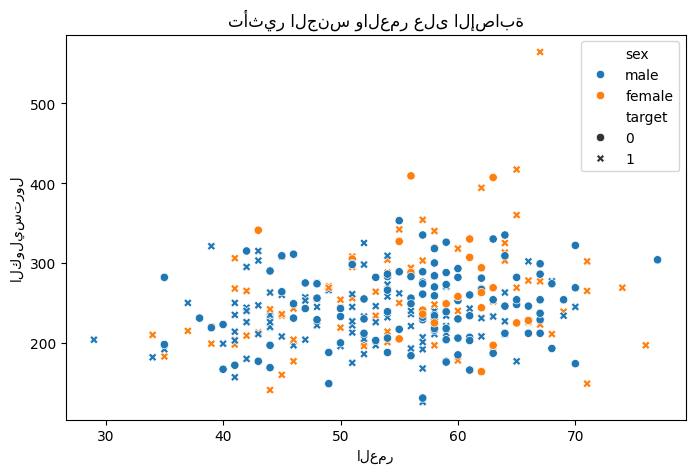

In [46]:
# تأثير الجنس والعمر على الإصابة

plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='cholesterol', hue='sex', style='target')
plt.title("تأثير الجنس والعمر على الإصابة")
plt.xlabel("العمر")
plt.ylabel("الكوليسترول")
plt.show()

In [47]:
# ما هو متوسط عمر المرضى؟
mean=data['age'].mean()
print(mean)
# ما هو متوسط ضغط الدم للمرضى؟
print(data['resting_blood_pressure'].mean())


54.523648648648646
131.60472972972974


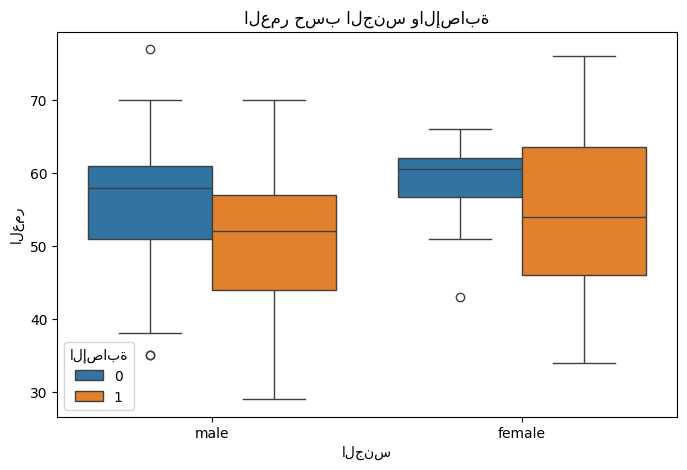

In [48]:

#هل يوجد اختلاف في العمر بين الجنسين عند الإصابة؟
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='sex', y='age', hue='target')
plt.title("العمر حسب الجنس والإصابة")
plt.xlabel("الجنس")
plt.ylabel("العمر")
plt.legend(title="الإصابة")
plt.show()


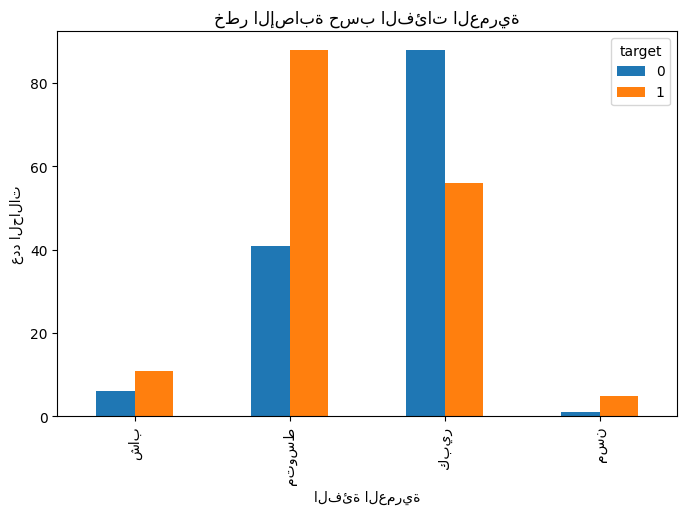

In [49]:
# هل هناك فرق إحصائي بين فئات العمر في خطر الإصابة؟

data['age_group'] = pd.cut(data['age'], bins=[20, 40, 55, 70, 100], labels=['شاب', 'متوسط', 'كبير', 'مسن'])
pd.crosstab(data['age_group'], data['target']).plot(kind='bar', figsize=(8,5))
plt.title("خطر الإصابة حسب الفئات العمرية")
plt.xlabel("الفئة العمرية")
plt.ylabel("عدد الحالات")
plt.show()

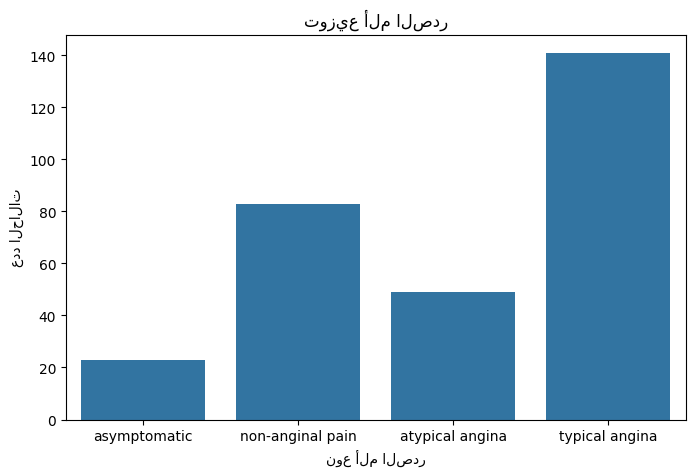

In [50]:
# ما هو التوزيع العام لأنواع ألم الصدر؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='chest_pain_type')
plt.title("توزيع ألم الصدر")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الحالات")
plt.show()

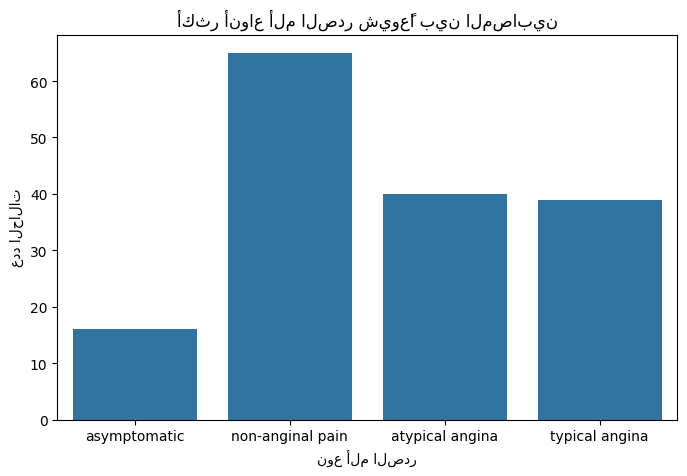

In [51]:
# ما نوع الألم الأكثر شيوعًا بين المصابين؟

plt.figure(figsize=(8,5))
sns.countplot(data=data[data['target']==1], x='chest_pain_type')
plt.title("أكثر أنواع ألم الصدر شيوعًا بين المصابين")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الحالات")
plt.show()

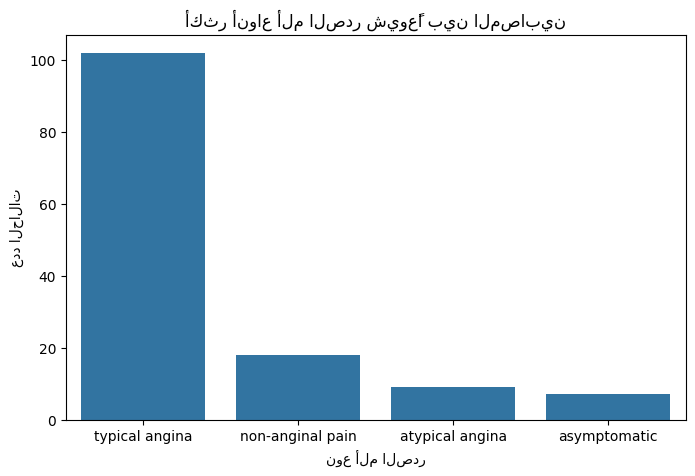

In [52]:
# ما نوع الألم الأكثر شيوعًا بين الغير المصابين؟

plt.figure(figsize=(8,5))
sns.countplot(data=data[data['target']==0], x='chest_pain_type')
plt.title("أكثر أنواع ألم الصدر شيوعًا بين المصابين")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الحالات")
plt.show()

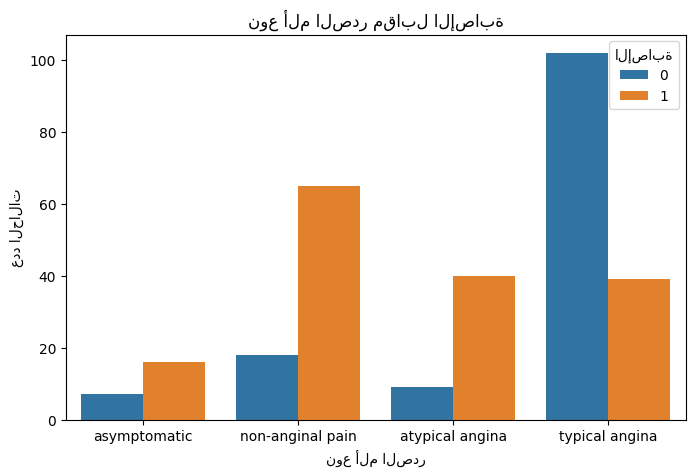

In [53]:
# هل نوع ألم الصدر مرتبط بالنتيجة النهائية؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='chest_pain_type', hue='target')
plt.title("نوع ألم الصدر مقابل الإصابة")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الحالات")
plt.legend(title="الإصابة")
plt.show()

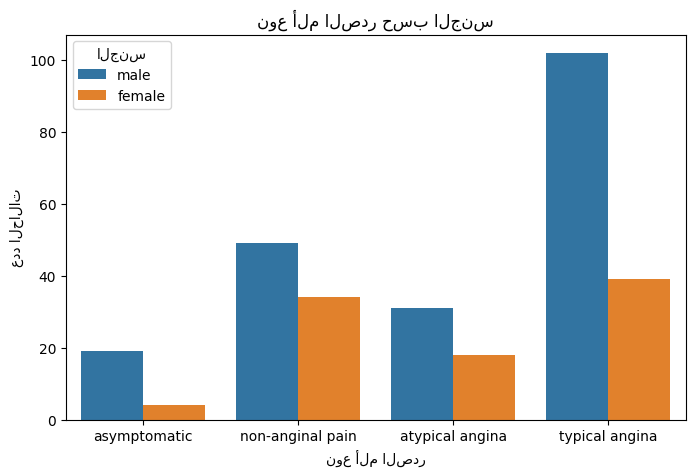

In [54]:
# هل يختلف تأثير نوع ألم الصدر حسب الجنس؟

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='chest_pain_type', hue='sex')
plt.title("نوع ألم الصدر حسب الجنس")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("عدد الحالات")
plt.legend(title="الجنس")
plt.show()

In [55]:
print(data['max_heart_rate_achieved'].mean())
print(data[data['target'] == 1]['max_heart_rate_achieved'].max())

149.5608108108108
202


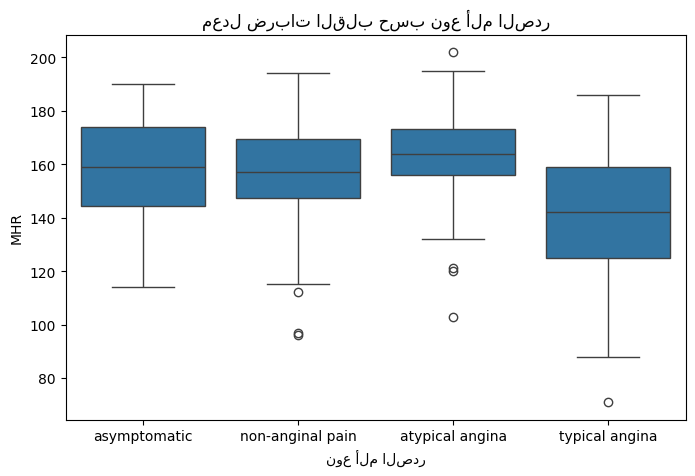

In [56]:
# هل ضربات القلب مرتبطة بألم الصدر؟

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='chest_pain_type', y='max_heart_rate_achieved')
plt.title("معدل ضربات القلب حسب نوع ألم الصدر")
plt.xlabel("نوع ألم الصدر")
plt.ylabel("MHR")
plt.show()

####  خريطة الارتباط بين المتغيرات الرقمية

#### ما المتغيرات الاكثر ارتباطا بوجود المرض؟ 

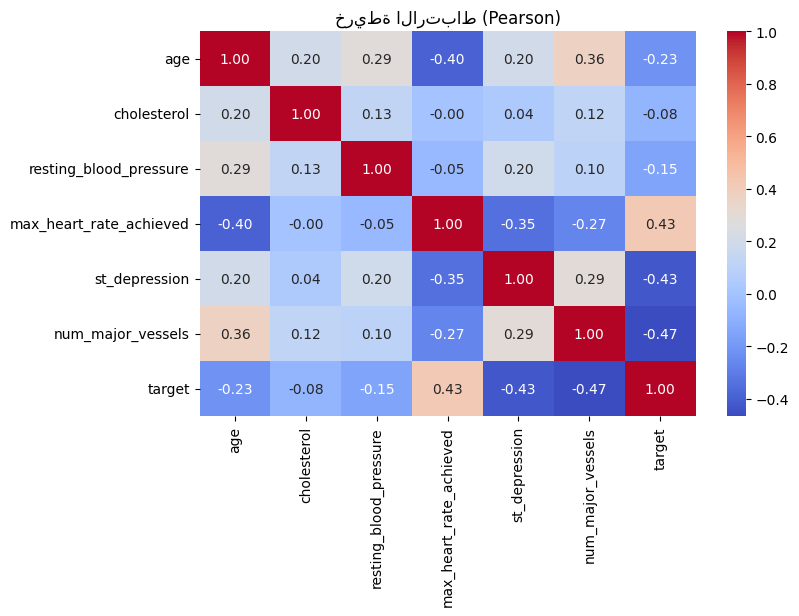

In [57]:

plt.figure(figsize=(8, 5))
corr = data[num_feats + ['target']].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("خريطة الارتباط (Pearson)")
plt.show()

## **1.5 EDA Summary**: <a class="anchor" id="1.5"></a>

* Data size: 303 rows and 14 columns (13 independent + one target variable) > later reduced to 296 after removing faulty data points!
* Data has no missing values
* Features (columns) data type: 
    * Six features are numerical 
    * The rest (seven features) are categorical variables
* Target variable is fairly balanced, 54% no-disease to 46% has-disease
* Correlations:
    * Correlation between features is weak at best
    * From the numerical features `num_major_vessels`, `max_heart_rate_achieved` and `st_depression` are reasonabily fairly correlated with the target variable at -0.47, 0.43 and -0.43 correlation coefficient respectively.
    * From the categorical features `chest_pain_type`, `num_major_vessels`, `thalassemia`, and `exercise_induced_angina` are better correlated with the target variable, `thalassemia` being the highest at 0.52.
    * Cholestrol (to my surprize, but what do I know?) has less correlation with heart desease. 
    
**Takeaway**: features that have higher predictive power could be, **`chest_pain_type`, `num_major_vessels`, `thalassemia`, `exercise_induced_angina` `max_heart_rate_achieved`** and **`st_depression`**. We will see which features will appear as imporatnt by the classification models.

## **الملخص النهائي لاستنتاجات بيانات القلب**: <a class="anchor" id="1.5"></a>

1. الوصفي (Descriptive)

العينة: 303 مريض.
الجنس: 68% رجال و32% نساء.
متوسط العمر: حوالي 54 سنة (الأغلب بين 47–61 سنة).
الكولسترول: يتراوح بين أقل من 200 إلى أكثر من 500 mg/dl، بمتوسط 240–250.
ضغط الدم أثناء الراحة: غالبًا بين 130–140 mmHg.
نوع ألم الصدر الأكثر شيوعًا: asymptomatic (غياب الأعراض لا يعني غياب المرض).

2. التشخيصي (Diagnostic)

المرضى المصابون (target=1) غالبًا:
أكبر عمرًا من غير المصابين.
لديهم كولسترول وضغط دم أعلى.
معدل نبض أقصى (thalach) أقل.
يظهر لديهم ST depression وعدد أوعية متأثرة أكبر.
النساء أقل عددًا، لكن عند وجود إصابة يكون تأثير الكولسترول والضغط أكثر وضوحًا.

3. التنبؤي (Predictive)

المتغيرات الأقوى للتنبؤ بالإصابة:
chest pain type (cp)
oldpeak (st_depression)
ca (num_major_vessels)
thalach (max_heart_rate)
age
غياب الألم الصدري (asymptomatic) لا يعني السلامة، بل هو من أقوى المؤشرات على المرض.
بعد عمر الخمسين تزداد احتمالية الإصابة بشكل ملحوظ.

4. التوجيهي (Prescriptive)

الإجراءات الطبية والوقائية ينبغي أن تركز على:
ضبط ضغط الدم والكولسترول بشكل دوري.
إجراء فحوصات ECG واختبارات الجهد حتى في حالة غياب الأعراض.
متابعة المرضى ممن لديهم عدة أوعية متأثرة بدقة، لأن الخطر يرتفع مع العدد.
الكشف المبكر (screening) أولوية للفئة فوق 50 عامًا.

5. المقارن (Comparative)

الرجال أكثر عددًا في العينة، لكن نسبة الإصابة بين النساء (إذا وُجدت عوامل خطر) تميل أن تكون مرتفعة.
هذا يوحي بأن النساء قد يبدون أقل عرضة عدديًا، لكن الخطر عند إصابتهن يكون أشد.

6. السببي (Causal-style)

ضغط الدم المرتفع مع العمر عاملان متفاعلان يزيدان من احتمالية الإصابة.
خفض الضغط أو الكولسترول بنسبة 10% قد يؤدي إلى تقليل كبير في الخطر، خصوصًا عند من لديهم أوعية متأثرة.

7. الاستكشافي (Exploratory)

هناك أنماط ضمنية يمكن استكشافها بالـ Clustering:
مجموعة من الشباب بأعمار صغيرة مع عوامل قليلة.
مجموعة من كبار السن مع عوامل متعددة (ضغط، كولسترول، أوعية).

8. ماذا لو (What-if)

ماذا لو زاد العمر إلى 60 سنة؟
حتى مع كولسترول طبيعي، يظل خطر الإصابة مرتفعًا بسبب العمر وضغط الدم.
ماذا لو تحكمنا في الكولسترول؟
يقل الخطر بشكل كبير، خصوصًا عند المرضى في منتصف العمر.

9. التجزئة (Segmentation)

يمكن تقسيم المرضى إلى شرائح سريرية:
مرضى مع oldpeak منخفض + thalach مرتفع (خطر أقل).
مرضى مع oldpeak مرتفع + thalach منخفض (خطر أعلى).
هذا التقسيم يساعد في تخصيص العلاج لكل مجموعة.





            

# ML

#✅ الخصائص ذات التأثير القوي كما في التحليل السابق (EDA)

🔹 الخصائص الرقمية:
num_major_vessels,
max_heart_rate_achieved,
st_depression,
age

🔹 الخصائص التصنيفية:
chest_pain_type,
thalassemia,
exercise_induced_angina

### 🔹 1. تحديد الميزات المهمة فقط

In [58]:
selected_features = [
    'num_major_vessels',
    'max_heart_rate_achieved',
    'st_depression',
    'chest_pain_type',
    'thalassemia',
    'exercise_induced_angina',
    'age',
    
    
]

### 🔹 2. تجهيز البيانات


#### تقسيم البيانات لمتغيرات المستقله والتابعة

In [59]:
X = data[selected_features]
y = data['target']

X = data_with_missing.drop(columns=['target'])
y = original_data['target']  # الأصلية لأننا لا نحذف منها


#### تحويل الميزات التصنيفية إلى أرقام (One-Hot Encoding)

In [60]:
X = pd.get_dummies(X, drop_first=True)

#### تقسيم البيانات لتدريب والاختبار

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### توحيد الميزات الرقمية

In [62]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### التدريب

In [63]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred = model.predict(X_test)

print("📊 دقة النموذج:",( accuracy_score(y_test, y_pred))*100)
print("\n🧾 تقرير التصنيف:\n", classification_report(y_test, y_pred))
print("\n🧮 مصفوفة الالتباس:\n", confusion_matrix(y_test, y_pred))

📊 دقة النموذج: 83.60655737704919

🧾 تقرير التصنيف:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


🧮 مصفوفة الالتباس:
 [[24  5]
 [ 5 27]]


In [65]:
# نموذج راندم فورست
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)

# Cross-validation (5-fold)
rf_scores = cross_val_score(rf, X, y, cv=10, scoring="accuracy")

print("Random Forest CV scores:", rf_scores*100)
print("Random Forest mean accuracy:", np.mean(rf_scores)*100)


Random Forest CV scores: [93.5483871  87.09677419 90.32258065 93.33333333 93.33333333 83.33333333
 73.33333333 90.         80.         86.66666667]
Random Forest mean accuracy: 87.09677419354837


### تجريب النموذج

In [66]:
def predict_heart_disease(model, scaler):

    # === 1) إدخال المستخدم ===
    print("\n🔍 أدخل بيانات المريض:")
    num_major_vessels = input("عدد الأوعية الرئيسية (0-3): ").strip()
    max_heart_rate    = input("الحد الأقصى لمعدل ضربات القلب: ").strip()
    st_depression     = input("مستوى الاكتئاب ST: ").strip()
    age               = input('ادخل العمر: ').strip()

    chest_pain_type   = input("نوع ألم الصدر (typical angina / atypical angina / non-anginal pain / asymptomatic أو 0/1/2/3/4): ").strip()
    thalassemia       = input("الثلاسيميا (normal / fixed defect / reversible defect أو 1/2/3 أو 3/6/7): ").strip()
    exercise_angina   = input("ذبحه صدرية ناتجة عن التمرين؟ (yes / no أو 1/0): ").strip()

    # === 2) توحيد المدخلات (قبول نص/رقم) ===
    # تحويل الأوعية إلى عدد صحيح ضمن [0..3]
    def parse_int_in_range(val, lo, hi, name):
        try:
            v = int(float(val))
        except Exception:
            raise ValueError(f"قيمة {name} غير صالحة: {val}")
        if v < lo:
            print(f"⚠️ {name} أقل من {lo}، سيتم ضبطه إلى {lo}.")
            v = lo
        if v > hi:
            print(f"⚠️ {name} أكبر من {hi}، سيتم ضبطه إلى {hi}.")
            v = hi
        return v

    num_major_vessels = parse_int_in_range(num_major_vessels, 0, 3, "عدد الأوعية الرئيسية")
    max_heart_rate    = parse_int_in_range(max_heart_rate, 1, 400, "الحد الأقصى لمعدل ضربات القلب")  # حد منطقي واسع
    age               = parse_int_in_range(age,1,100,'الحد الاقصى للعمر ')
    try:
        st_depression = float(st_depression)
    except Exception:
        raise ValueError(f"قيمة ST غير صالحة: {st_depression}")

    # chest pain: قبول نصوص وأرقام (0/1/2/3/4 أو 1/2/3/4 حسب النسخة)
    cp_map = {
        "0": "typical angina",
        "1": "typical angina",
        "2": "atypical angina",
        "3": "non-anginal pain",
        "4": "asymptomatic",
        "typical": "typical angina",
        "typical angina": "typical angina",
        "atypical": "atypical angina",
        "atypical angina": "atypical angina",
        "non-anginal": "non-anginal pain",
        "non-anginal pain": "non-anginal pain",
        "asymptomatic": "asymptomatic",
    }
    cp_key = chest_pain_type.lower()
    chest_pain_type = cp_map.get(cp_key, cp_map.get(str(cp_key), cp_key))  # إن لم يجد، يتركها كما هي

    # thalassemia: قبول 3/6/7 أو 1/2/3 أو نصوص
    th_map = {
        "1": "normal", "3": "normal",    # بعض النسخ 3=normal، وبعضها 1=normal
        "2": "fixed defect", "6": "fixed defect",
        "3x": "reversible defect", "7": "reversible defect",  # نستخدم "3x" للتمييز عن "3" الأولى
        "normal": "normal",
        "fixed": "fixed defect",
        "fixed defect": "fixed defect",
        "reversable defect": "reversible defect",  # إملاء شائع
        "reversible defect": "reversible defect",
        "rev": "reversible defect"
    }
    tkey = thalassemia.lower()
    if tkey in {"3","6","7","1","2"}:
        # تمييز "3" الأولى كـ normal إن وردت بصيغة 1/2/3، أما "3" (Cleveland) فهي normal أيضًا (موحَّدة لأمان أكبر)
        if tkey == "3":
            thalassemia = "normal"
        elif tkey == "6":
            thalassemia = "fixed defect"
        elif tkey == "7":
            thalassemia = "reversible defect"
        elif tkey == "1":
            thalassemia = "normal"
        elif tkey == "2":
            thalassemia = "fixed defect"
    else:
        thalassemia = th_map.get(tkey, tkey)

    # exang: 1/0 أو yes/no
    ang_map = {"1": "yes", "0": "no", "yes":"yes", "y":"yes", "no":"no", "n":"no"}
    exercise_induced_angina = ang_map.get(exercise_angina.lower(), exercise_angina.lower())

    # === 3) بناء DataFrame بإسماء أعمدة التدريب الأصلية ===
    user_df = pd.DataFrame({
        'num_major_vessels': [num_major_vessels],
        'max_heart_rate_achieved': [max_heart_rate],
        'st_depression': [st_depression],
        'chest_pain_type': [chest_pain_type],
        'thalassemia': [thalassemia],
        'exercise_induced_angina': [exercise_induced_angina],
        'age':[age]
    })

    # === 4) One-Hot بنفس أسلوب التدريب ثم إعادة الفهرسة لمطابقة X.columns ===
    user_df = pd.get_dummies(user_df)
    # ⚠️ يفترض وجود X.columns في النطاق العام (نفس ما درّبت عليه). بديل: مرّرها كوسيط للدالة.
    user_df = user_df.reindex(columns=X.columns, fill_value=0)

    # === 5) التوحيد ثم التنبؤ ===
    user_scaled = scaler.transform(user_df)

    if hasattr(model, "predict_proba"):
        proba_vec = model.predict_proba(user_scaled)[0]
        prediction = int(model.predict(user_scaled)[0])
        proba = proba_vec[prediction]
    else:
        prediction = int(model.predict(user_scaled)[0])
        proba = None
    # === 6) طباعـة النتيجة ===
    print("\n📌 النتيجة:")
    if prediction == 1:
        if proba is not None:
            print(f"⚠️ يُحتمل وجود مرض قلبي بنسبة {proba*100:.2f}%")
        else:
            print("⚠️ يُحتمل وجود مرض قلبي (النموذج لا يُرجِع احتمالات).")
    else:
        if proba is not None:
            print(f"✅ لا توجد مؤشرات مرض قلبي بنسبة {proba*100:.2f}%")
        else:
            print("✅ لا توجد مؤشرات مرض قلبي (النموذج لا يُرجِع احتمالات).")


In [67]:
#predict_heart_disease(model, scaler)